# 08 — Evaluation
**Dự án:** Latent Manipulation of Brain MRI using Volume-Preserving GANs

**Metrics đánh giá 4 model:**
- **SSIM** — đo trên **test set** (không phải train set), dùng đúng indices đã lưu trong checkpoint
- **FID** (Fréchet Inception Distance) — đo phân bố ảnh fake vs ảnh thật trên test set
- **Loss_G** — WGAN loss Generator tốt nhất

**Output:**
```
evaluation/
├── metrics_summary.json
├── loss_curves.png
└── real_vs_fake.png
```

## Bước 1: Cấu hình

In [1]:
import os, json

# ==== CHECKPOINTS ====
MODEL_2D_NORM_PATH   = '/kaggle/input/datasets/dyio147/gan2d-normalized/best_model.pth'
MODEL_2D_UNNORM_PATH = '/kaggle/input/datasets/cminhnguyndsdsds/gan2d-unnormalized/best_model.pth'
MODEL_3D_NORM_PATH   = '/kaggle/input/datasets/dyio147/gan3d-normalized/best_model.pth'
MODEL_3D_UNNORM_PATH = '/kaggle/input/datasets/cminhnguyndsdsds/gan3d-unnormalized/best_model.pth'

# ==== DATA ====
DATA_2D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/normalized'
DATA_2D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/unnormalized'
DATA_3D_NORM_DIR   = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/normalized'
DATA_3D_UNNORM_DIR = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/unnormalized'
LABELS_2D_CSV      = '/kaggle/input/datasets/minhbodoi/full-preprocessed-2d/preprocessed_2d/preprocessing_log.csv'
LABELS_3D_CSV      = '/kaggle/input/datasets/minhbodoi/3000-preprocessed-3d/preprocessed_3d/preprocessing_log.csv'

OUTPUT_DIR = '/kaggle/working/evaluation'
os.makedirs(OUTPUT_DIR, exist_ok=True)

LATENT_DIM = 256
print('Cấu hình xong!')


Cấu hình xong!


## Bước 2: Import thư viện

In [2]:
!pip install nibabel scikit-image pytorch-fid SynthSeg-package -q 2>/dev/null || true
!pip install antspyx -q 2>/dev/null || true

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import pandas as pd
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 8.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 41.0 MB/s eta 0:00:0000:01:00:01
Device: cuda


## Bước 3: Định nghĩa kiến trúc model

In [3]:
class AgeEmbedding(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 128), nn.ReLU(), nn.Linear(128, embed_dim))
    def forward(self, age): return self.net(age.unsqueeze(-1))


class UNetBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm2d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator2D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed = AgeEmbedding(latent_dim)
        self.age_proj  = nn.Linear(latent_dim, 512)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True);           self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True);           self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True);           self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=UNetBlock2D(512,512,down=False,dropout=True);  self.d2=UNetBlock2D(1024,512,down=False,dropout=True)
        self.d3=UNetBlock2D(1024,512,down=False,dropout=True); self.d4=UNetBlock2D(1024,512,down=False)
        self.d5=UNetBlock2D(1024,256,down=False);              self.d6=UNetBlock2D(512,128,down=False)
        self.d7=UNetBlock2D(256,64,down=False)
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x);e2=self.e2(e1);e3=self.e3(e2);e4=self.e4(e3)
        e5=self.e5(e4);e6=self.e6(e5);e7=self.e7(e6);e8=self.e8(e7)
        z=e8+self.age_proj(self.age_embed(age)).view(-1,512,1,1)
        d1=self.d1(z);d2=self.d2(torch.cat([d1,e7],1));d3=self.d3(torch.cat([d2,e6],1))
        d4=self.d4(torch.cat([d3,e5],1));d5=self.d5(torch.cat([d4,e4],1))
        d6=self.d6(torch.cat([d5,e3],1));d7=self.d7(torch.cat([d6,e2],1))
        return self.out(torch.cat([d7,e1],1))


class UNetBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down : layers.append(nn.Conv3d(in_ch, out_ch, 4, 2, 1, bias=False))
        else    : layers.append(nn.ConvTranspose3d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn  : layers.append(nn.BatchNorm3d(out_ch))
        if dropout : layers.append(nn.Dropout(0.5))
        layers.append(nn.LeakyReLU(0.2) if down else nn.ReLU())
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator3D(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.age_embed=AgeEmbedding(latent_dim); self.age_proj=nn.Linear(latent_dim,256)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True);             self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=UNetBlock3D(256,128,down=False,dropout=True); self.d2=UNetBlock3D(256,64,down=False)
        self.d3=UNetBlock3D(128,32,down=False)
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
    def forward(self, x, age):
        e1=self.e1(x);e2=self.e2(e1);e3=self.e3(e2);e4=self.e4(e3)
        z=e4+self.age_proj(self.age_embed(age)).view(-1,256,1,1,1)
        d1=self.d1(z);d2=self.d2(torch.cat([d1,e3],1));d3=self.d3(torch.cat([d2,e2],1))
        return self.out(torch.cat([d3,e1],1))


class MappingNetwork(nn.Module):
    def __init__(self, latent_dim=256, w_dim=512, n_layers=4):
        super().__init__()
        layers = [AgeEmbedding(latent_dim), nn.ReLU()]
        in_dim = latent_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, w_dim), nn.ReLU()]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, w_dim)
    def forward(self, age): return self.out(self.net(age))

class AdaIN2D(nn.Module):
    def __init__(self, channels, w_dim=512):
        super().__init__()
        self.norm  = nn.InstanceNorm2d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)
    def forward(self, x, w):
        style = self.style(w).unsqueeze(-1).unsqueeze(-1)
        scale, shift = style.chunk(2, dim=1)
        return scale * self.norm(x) + shift

class Generator2D_StyleGAN(nn.Module):
    def __init__(self, latent_dim=256, w_dim=512):
        super().__init__()
        self.mapping = MappingNetwork(latent_dim, w_dim)
        self.e1=UNetBlock2D(1,64,down=True,use_bn=False); self.e2=UNetBlock2D(64,128,down=True)
        self.e3=UNetBlock2D(128,256,down=True); self.e4=UNetBlock2D(256,512,down=True)
        self.e5=UNetBlock2D(512,512,down=True); self.e6=UNetBlock2D(512,512,down=True)
        self.e7=UNetBlock2D(512,512,down=True); self.e8=UNetBlock2D(512,512,down=True,use_bn=False)
        self.d1=nn.Sequential(nn.ConvTranspose2d(512,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d2=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d3=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d4=nn.Sequential(nn.ConvTranspose2d(1024,512,4,2,1,bias=False),nn.ReLU())
        self.d5=nn.Sequential(nn.ConvTranspose2d(1024,256,4,2,1,bias=False),nn.ReLU())
        self.d6=nn.Sequential(nn.ConvTranspose2d(512,128,4,2,1,bias=False),nn.ReLU())
        self.d7=nn.Sequential(nn.ConvTranspose2d(256,64,4,2,1,bias=False),nn.ReLU())
        self.out=nn.Sequential(nn.ConvTranspose2d(128,1,4,2,1),nn.Tanh())
        self.adain1=AdaIN2D(512,w_dim); self.adain2=AdaIN2D(512,w_dim); self.adain3=AdaIN2D(512,w_dim)
        self.adain4=AdaIN2D(512,w_dim); self.adain5=AdaIN2D(256,w_dim)
        self.adain6=AdaIN2D(128,w_dim); self.adain7=AdaIN2D(64,w_dim)
    def forward(self, x, age):
        w=self.mapping(age)
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); e8=self.e8(e7)
        d1=self.adain1(self.d1(e8),w); d2=self.adain2(self.d2(torch.cat([d1,e7],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e6],1)),w); d4=self.adain4(self.d4(torch.cat([d3,e5],1)),w)
        d5=self.adain5(self.d5(torch.cat([d4,e4],1)),w); d6=self.adain6(self.d6(torch.cat([d5,e3],1)),w)
        d7=self.adain7(self.d7(torch.cat([d6,e2],1)),w)
        return self.out(torch.cat([d7,e1],1))

class AdaIN3D(nn.Module):
    def __init__(self, channels, w_dim=256):
        super().__init__()
        self.norm  = nn.InstanceNorm3d(channels, affine=False)
        self.style = nn.Linear(w_dim, channels * 2)
    def forward(self, x, w):
        style = self.style(w).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        scale, shift = style.chunk(2, dim=1)
        return scale * self.norm(x) + shift

class MappingNetwork3D(nn.Module):
    def __init__(self, latent_dim=256, w_dim=256, n_layers=4):
        super().__init__()
        layers = [AgeEmbedding(latent_dim), nn.ReLU()]
        in_dim = latent_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(in_dim, w_dim), nn.ReLU()]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, w_dim)
    def forward(self, age): return self.out(self.net(age))

class Generator3D_StyleGAN(nn.Module):
    def __init__(self, latent_dim=256, w_dim=256):
        super().__init__()
        self.mapping = MappingNetwork3D(latent_dim, w_dim)
        self.e1=UNetBlock3D(1,32,down=True,use_bn=False); self.e2=UNetBlock3D(32,64,down=True)
        self.e3=UNetBlock3D(64,128,down=True); self.e4=UNetBlock3D(128,256,down=True,use_bn=False)
        self.d1=nn.Sequential(nn.ConvTranspose3d(256,128,4,2,1,bias=False),nn.Dropout(0.5),nn.ReLU())
        self.d2=nn.Sequential(nn.ConvTranspose3d(256,64,4,2,1,bias=False),nn.ReLU())
        self.d3=nn.Sequential(nn.ConvTranspose3d(128,32,4,2,1,bias=False),nn.ReLU())
        self.out=nn.Sequential(nn.ConvTranspose3d(64,1,4,2,1),nn.Tanh())
        self.adain1=AdaIN3D(128,w_dim); self.adain2=AdaIN3D(64,w_dim); self.adain3=AdaIN3D(32,w_dim)
    def forward(self, x, age):
        w=self.mapping(age)
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        d1=self.adain1(self.d1(e4),w); d2=self.adain2(self.d2(torch.cat([d1,e3],1)),w)
        d3=self.adain3(self.d3(torch.cat([d2,e2],1)),w)
        return self.out(torch.cat([d3,e1],1))

def auto_load_2d(path):
    ckpt = torch.load(path, map_location=DEVICE)
    keys = list(ckpt['G_state'].keys())
    G = Generator2D_StyleGAN(LATENT_DIM).to(DEVICE) if any('mapping' in k for k in keys) else Generator2D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval()
    return G, ckpt

def auto_load_3d(path):
    ckpt = torch.load(path, map_location=DEVICE)
    keys = list(ckpt['G_state'].keys())
    G = Generator3D_StyleGAN(LATENT_DIM).to(DEVICE) if any('mapping' in k for k in keys) else Generator3D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval()
    return G, ckpt

def load_model_2d(path):
    ckpt=torch.load(path,map_location=DEVICE)
    keys=list(ckpt['G_state'].keys())
    G = Generator2D_StyleGAN(LATENT_DIM).to(DEVICE) if any('mapping' in k for k in keys) else Generator2D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval(); return G, ckpt

def load_model_3d(path):
    ckpt=torch.load(path,map_location=DEVICE)
    keys=list(ckpt['G_state'].keys())
    G = Generator3D_StyleGAN(LATENT_DIM).to(DEVICE) if any('mapping' in k for k in keys) else Generator3D(LATENT_DIM).to(DEVICE)
    G.load_state_dict(ckpt['G_state']); G.eval(); return G, ckpt



## Bước 4: Dataset — dùng đúng Test Set từ checkpoint

Các model đã lưu `test_indices` khi train. Evaluation chỉ chạy trên phần data **chưa từng thấy** trong training.

In [4]:
class Dataset2D(Dataset):
    def __init__(self, data_dir, labels_csv, age_min, age_max):
        self.age_min = age_min; self.age_max = age_max
        df = pd.read_csv(labels_csv)
        df['full_path'] = df['png_file'].apply(lambda x: os.path.join(data_dir, x))
        self.df = df[df['full_path'].apply(os.path.exists)].reset_index(drop=True)
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
    def normalize_age(self, age):
        return 2 * (age - self.age_min) / (self.age_max - self.age_min) - 1
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.transform(Image.open(row['full_path']).convert('L'))
        return img, torch.tensor(self.normalize_age(row['age']), dtype=torch.float32)


def find_nii(data_dir, subject_id):
    for ext in ['.nii.gz', '.nii']:
        path = os.path.join(data_dir, f'{subject_id}{ext}')
        if os.path.exists(path): return path
    return None


class Dataset3D(Dataset):
    def __init__(self, data_dir, labels_csv, age_min, age_max, volume_size):
        self.age_min = age_min; self.age_max = age_max; self.volume_size = volume_size
        df = pd.read_csv(labels_csv)
        df['nii_path'] = df['subject_id'].apply(lambda x: find_nii(data_dir, x))
        self.df = df[df['nii_path'].notna()].reset_index(drop=True)
    def normalize_age(self, age):
        return 2 * (age - self.age_min) / (self.age_max - self.age_min) - 1
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        data = nib.load(row['nii_path']).get_fdata().astype(np.float32)
        vol = torch.tensor(data).unsqueeze(0).unsqueeze(0)
        vol = F.interpolate(vol, size=(self.volume_size,)*3,
                            mode='trilinear', align_corners=False)
        return vol.squeeze(0)*2-1, torch.tensor(self.normalize_age(row['age']),
                                                 dtype=torch.float32)


def make_test_loader_2d(data_dir, labels_csv, ckpt, batch_size=8):
    """Tạo loader chỉ gồm test set — dùng test_indices đã lưu trong checkpoint."""
    full_ds = Dataset2D(data_dir, labels_csv, ckpt['age_min'], ckpt['age_max'])
    if 'test_indices' in ckpt:
        test_ds = Subset(full_ds, ckpt['test_indices'])
        print(f'  → Dùng test_indices từ checkpoint: {len(test_ds)} ảnh')
    else:
        # Fallback: dùng 20% cuối nếu checkpoint cũ không có test_indices
        n = len(full_ds)
        test_ds = Subset(full_ds, list(range(int(0.8*n), n)))
        print(f'  → Không có test_indices, dùng 20% cuối: {len(test_ds)} ảnh')
    return DataLoader(test_ds, batch_size=batch_size, shuffle=False)


def make_test_loader_3d(data_dir, labels_csv, ckpt):
    full_ds = Dataset3D(data_dir, labels_csv, ckpt['age_min'], ckpt['age_max'],
                        ckpt.get('volume_size', 64))
    if 'test_indices' in ckpt:
        test_ds = Subset(full_ds, ckpt['test_indices'])
        print(f'  → Dùng test_indices từ checkpoint: {len(test_ds)} subjects')
    else:
        n = len(full_ds)
        test_ds = Subset(full_ds, list(range(int(0.8*n), n)))
        print(f'  → Không có test_indices, dùng 20% cuối: {len(test_ds)} subjects')
    return DataLoader(test_ds, batch_size=1, shuffle=False)



## Bước 5: Tính SSIM + FID trên Test Set

In [7]:
# Thêm vào đầu cell 5, TRƯỚC dòng "Đang tính SSIM..."
print('Loading models...')
G2D_norm,   ck2n = load_model_2d(MODEL_2D_NORM_PATH)
G2D_unnorm, ck2u = load_model_2d(MODEL_2D_UNNORM_PATH)
G3D_norm,   ck3n = load_model_3d(MODEL_3D_NORM_PATH)
G3D_unnorm, ck3u = load_model_3d(MODEL_3D_UNNORM_PATH)

loader_2d_norm   = make_test_loader_2d(DATA_2D_NORM_DIR,   LABELS_2D_CSV, ck2n)
loader_2d_unnorm = make_test_loader_2d(DATA_2D_UNNORM_DIR, LABELS_2D_CSV, ck2u)
loader_3d_norm   = make_test_loader_3d(DATA_3D_NORM_DIR,   LABELS_3D_CSV, ck3n)
loader_3d_unnorm = make_test_loader_3d(DATA_3D_UNNORM_DIR, LABELS_3D_CSV, ck3u)

# ... phần còn lại của cell 5 giữ nguyên
# ── SSIM trên test set ───────────────────────────────────────────────────────
def eval_ssim_2d(G, loader, device):
    """SSIM reconstruction trên test set — data model chưa thấy khi train."""
    scores = []; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='SSIM 2D', leave=False):
            imgs = imgs.to(device); ages = ages.to(device)
            fakes = G(imgs, ages)
            for i in range(imgs.size(0)):
                r = (imgs[i, 0].cpu().numpy() + 1) / 2
                f = (fakes[i, 0].cpu().numpy() + 1) / 2
                scores.append(ssim(r, f, data_range=1.0))
    return float(np.mean(scores))


def eval_ssim_3d(G, loader, device):
    scores = []; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='SSIM 3D', leave=False):
            vols = vols.to(device); ages = ages.to(device)
            fakes = G(vols, ages)
            r = (vols[0, 0].cpu().numpy() + 1) / 2
            f = (fakes[0, 0].cpu().numpy() + 1) / 2
            scores.append(float(np.mean([ssim(r[i], f[i], data_range=1.0)
                                          for i in range(r.shape[0])])))
    return float(np.mean(scores))


# ── FID trên test set ─────────────────────────────────────────────────────────
def compute_fid_2d(G, loader, device):
    """
    FID đo xem ảnh fake có phân bố giống ảnh thật không.
    Dùng InceptionV3 features (channel 1 → repeat 3 để phù hợp Inception).
    """
    from torchvision.models import inception_v3
    from scipy.linalg import sqrtm

    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.fc = nn.Identity()  # lấy feature 2048-dim
    inception.eval()

    def get_features(loader, fake=False):
        feats = []
        with torch.no_grad():
            for imgs, ages in tqdm(loader, desc='FID features', leave=False):
                imgs = imgs.to(device); ages = ages.to(device)
                if fake:
                    imgs = G(imgs, ages)
                # Inception cần 3 channel và 299x299
                imgs_3ch = imgs.repeat(1, 3, 1, 1)
                imgs_3ch = F.interpolate(imgs_3ch, size=(299, 299),
                                         mode='bilinear', align_corners=False)
                # Normalize về ImageNet range
                imgs_3ch = (imgs_3ch + 1) / 2  # [-1,1] → [0,1]
                feat = inception(imgs_3ch)
                feats.append(feat.cpu().numpy())
        return np.concatenate(feats, axis=0)

    real_feats = get_features(loader, fake=False)
    fake_feats = get_features(loader, fake=True)

    mu_r, sigma_r = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu_f, sigma_f = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)

    diff = mu_r - mu_f
    covmean = sqrtm(sigma_r @ sigma_f)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = float(diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean))
    return fid


# ── Tính tất cả metrics ───────────────────────────────────────────────────────
print('Đang tính SSIM trên test set...')
ssim_2d_norm   = eval_ssim_2d(G2D_norm,   loader_2d_norm,   DEVICE)
ssim_2d_unnorm = eval_ssim_2d(G2D_unnorm, loader_2d_unnorm, DEVICE)
ssim_3d_norm   = eval_ssim_3d(G3D_norm,   loader_3d_norm,   DEVICE)
ssim_3d_unnorm = eval_ssim_3d(G3D_unnorm, loader_3d_unnorm, DEVICE)

print('\nĐang tính FID trên test set (chậm hơn — cần InceptionV3)...')
fid_2d_norm   = compute_fid_2d(G2D_norm,   loader_2d_norm,   DEVICE)
fid_2d_unnorm = compute_fid_2d(G2D_unnorm, loader_2d_unnorm, DEVICE)
# 3D: lấy axial slice giữa rồi tính FID như 2D
print('  → FID 3D: tính trên axial slice giữa của mỗi volume')

def make_axial_loader(G_3d, loader_3d, device, volume_size):
    """Convert 3D volumes → axial slice 2D để tính FID."""
    real_slices, fake_slices = [], []
    G_3d.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader_3d, desc='Extract axial', leave=False):
            vols = vols.to(device); ages = ages.to(device)
            fakes = G_3d(vols, ages)
            mid = volume_size // 2
            real_slices.append(vols[0, :, mid, :, :].unsqueeze(0).cpu())
            fake_slices.append(fakes[0, :, mid, :, :].unsqueeze(0).cpu())
    return torch.cat(real_slices), torch.cat(fake_slices)

def fid_from_tensors(real_t, fake_t, device):
    from torchvision.models import inception_v3
    from scipy.linalg import sqrtm
    inception = inception_v3(pretrained=True, transform_input=False).to(device)
    inception.fc = nn.Identity(); inception.eval()
    def feats(t):
        out = []
        for i in range(0, len(t), 8):
            batch = t[i:i+8].repeat(1,3,1,1)
            batch = F.interpolate(batch, (299,299), mode='bilinear', align_corners=False)
            batch = (batch+1)/2
            with torch.no_grad():
                out.append(inception(batch.to(device)).cpu().numpy())
        return np.concatenate(out)
    rf = feats(real_t); ff = feats(fake_t)
    mu_r,sig_r = rf.mean(0), np.cov(rf, rowvar=False)
    mu_f,sig_f = ff.mean(0), np.cov(ff, rowvar=False)
    diff = mu_r-mu_f
    cov  = sqrtm(sig_r@sig_f)
    if np.iscomplexobj(cov): cov=cov.real
    return float(diff@diff + np.trace(sig_r+sig_f-2*cov))

real_3n, fake_3n     = make_axial_loader(G3D_norm,   loader_3d_norm,   DEVICE, ck3n.get('volume_size', 64))
real_3u, fake_3u     = make_axial_loader(G3D_unnorm, loader_3d_unnorm, DEVICE, ck3u.get('volume_size', 64))
fid_3d_norm   = fid_from_tensors(real_3n, fake_3n, DEVICE)
fid_3d_unnorm = fid_from_tensors(real_3u, fake_3u, DEVICE)

# ── Tổng kết ─────────────────────────────────────────────────────────────────
results = {
    'GAN_2D_normalized'  : {'best_loss_G': ck2n['best_loss_G'], 'ssim': ssim_2d_norm,
                             'fid': fid_2d_norm,   'best_epoch': ck2n['epoch'],
                             'val_ssim_checkpoint': ck2n.get('val_ssim', 'N/A')},
    'GAN_2D_unnormalized': {'best_loss_G': ck2u['best_loss_G'], 'ssim': ssim_2d_unnorm,
                             'fid': fid_2d_unnorm, 'best_epoch': ck2u['epoch'],
                             'val_ssim_checkpoint': ck2u.get('val_ssim', 'N/A')},
    'GAN_3D_normalized'  : {'best_loss_G': ck3n['best_loss_G'], 'ssim': ssim_3d_norm,
                             'fid': fid_3d_norm,   'best_epoch': ck3n['epoch'],
                             'val_ssim_checkpoint': ck3n.get('val_ssim', 'N/A')},
    'GAN_3D_unnormalized': {'best_loss_G': ck3u['best_loss_G'], 'ssim': ssim_3d_unnorm,
                             'fid': fid_3d_unnorm, 'best_epoch': ck3u['epoch'],
                             'val_ssim_checkpoint': ck3u.get('val_ssim', 'N/A')},
}

print('\n' + '='*75)
print('EVALUATION SUMMARY (trên TEST SET)')
print('='*75)
print(f'{"Model":<25} {"Epoch":>6} {"Loss_G":>8} {"SSIM↑":>8} {"FID↓":>10}')
print('-'*75)
for name, m in results.items():
    print(f'{name:<25} {m["best_epoch"]:>6} {m["best_loss_G"]:>8.4f} ',
          f'{m["ssim"]:>8.4f} {m["fid"]:>10.2f}')
print('='*75)
print('Ghi chú: SSIM↑ cao hơn tốt hơn | FID↓ thấp hơn tốt hơn')

with open(f'{OUTPUT_DIR}/metrics_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nKết quả lưu tại: {OUTPUT_DIR}/metrics_summary.json')


# ── PSNR trên test set ────────────────────────────────────────
def compute_psnr(r, f):
    mse = np.mean((r - f) ** 2)
    if mse == 0: return float('inf')
    return float(20 * np.log10(1.0 / np.sqrt(mse)))

def eval_psnr_2d(G, loader, device):
    scores = []; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='PSNR 2D', leave=False):
            imgs = imgs.to(device); ages = ages.to(device)
            fakes = G(imgs, ages)
            for i in range(imgs.size(0)):
                r = (imgs[i,0].cpu().numpy()+1)/2
                f = (fakes[i,0].cpu().numpy()+1)/2
                scores.append(compute_psnr(r, f))
    return float(np.mean(scores))

def eval_psnr_3d(G, loader, device):
    scores = []; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='PSNR 3D', leave=False):
            vols = vols.to(device); ages = ages.to(device)
            fakes = G(vols, ages)
            r = (vols[0,0].cpu().numpy()+1)/2
            f = (fakes[0,0].cpu().numpy()+1)/2
            scores.append(compute_psnr(r, f))
    return float(np.mean(scores))

# ── Volume Preservation Score ─────────────────────────────────
# Đo xem GAN có preserve volume não không bằng cách so sánh
# voxel intensity distribution của real vs fake
# (proxy cho volume vì không có SynthSeg trên Kaggle)
def eval_volume_preservation_2d(G, loader, device):
    """
    Volume Preservation Score (VPS):
    Đo sự khác biệt về tổng intensity (proxy cho tissue volume)
    giữa real và fake. VPS gần 1.0 = preserve tốt.
    """
    ratios = []; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='VPS 2D', leave=False):
            imgs = imgs.to(device); ages = ages.to(device)
            fakes = G(imgs, ages)
            for i in range(imgs.size(0)):
                r = (imgs[i,0].cpu().numpy()+1)/2
                f = (fakes[i,0].cpu().numpy()+1)/2
                vol_r = r.sum()
                vol_f = f.sum()
                if vol_r > 0:
                    ratios.append(vol_f / vol_r)
    mean_ratio = float(np.mean(ratios))
    vps = 1.0 - abs(1.0 - mean_ratio)
    return vps, mean_ratio

def eval_volume_preservation_3d(G, loader, device):
    ratios = []; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='VPS 3D', leave=False):
            vols = vols.to(device); ages = ages.to(device)
            fakes = G(vols, ages)
            r = (vols[0,0].cpu().numpy()+1)/2
            f = (fakes[0,0].cpu().numpy()+1)/2
            vol_r = r.sum()
            vol_f = f.sum()
            if vol_r > 0:
                ratios.append(vol_f / vol_r)
    mean_ratio = float(np.mean(ratios))
    vps = 1.0 - abs(1.0 - mean_ratio)
    return vps, mean_ratio
# ── PSNR ─────────────────────────────────────────────────────────────────────
def eval_psnr_2d(G, loader, device):
    scores = []; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='PSNR 2D', leave=False):
            imgs = imgs.to(device); ages = ages.to(device)
            fakes = G(imgs, ages)
            for i in range(imgs.size(0)):
                r = (imgs[i, 0].cpu().numpy() + 1) / 2
                f = (fakes[i, 0].cpu().numpy() + 1) / 2
                mse = np.mean((r - f) ** 2)
                scores.append(20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else 100.0)
    return float(np.mean(scores))

def eval_psnr_3d(G, loader, device):
    scores = []; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='PSNR 3D', leave=False):
            vols = vols.to(device); ages = ages.to(device)
            fakes = G(vols, ages)
            r = (vols[0, 0].cpu().numpy() + 1) / 2
            f = (fakes[0, 0].cpu().numpy() + 1) / 2
            mse = np.mean((r - f) ** 2)
            scores.append(20 * np.log10(1.0 / np.sqrt(mse)) if mse > 0 else 100.0)
    return float(np.mean(scores))


# ── Volume Preservation ───────────────────────────────────────────────────────
def eval_volume_preservation_2d(G, loader, device):
    """
    Đo xem vùng sáng (foreground) trong ảnh fake có giữ được kích thước so với ảnh real không.
    VPS = 1 - mean(|ratio - 1|), ratio = vol_fake / vol_real
    """
    ratios = []; G.eval()
    with torch.no_grad():
        for imgs, ages in tqdm(loader, desc='VolPres 2D', leave=False):
            imgs = imgs.to(device); ages = ages.to(device)
            fakes = G(imgs, ages)
            for i in range(imgs.size(0)):
                r = (imgs[i, 0].cpu().numpy() + 1) / 2
                f = (fakes[i, 0].cpu().numpy() + 1) / 2
                vol_r = np.sum(r > 0.1)
                vol_f = np.sum(f > 0.1)
                ratio = vol_f / vol_r if vol_r > 0 else 1.0
                ratios.append(ratio)
    ratios = np.array(ratios)
    vps = float(1 - np.mean(np.abs(ratios - 1)))
    return vps, float(np.mean(ratios))

def eval_volume_preservation_3d(G, loader, device):
    ratios = []; G.eval()
    with torch.no_grad():
        for vols, ages in tqdm(loader, desc='VolPres 3D', leave=False):
            vols = vols.to(device); ages = ages.to(device)
            fakes = G(vols, ages)
            r = (vols[0, 0].cpu().numpy() + 1) / 2
            f = (fakes[0, 0].cpu().numpy() + 1) / 2
            vol_r = np.sum(r > 0.1)
            vol_f = np.sum(f > 0.1)
            ratio = vol_f / vol_r if vol_r > 0 else 1.0
            ratios.append(ratio)
    ratios = np.array(ratios)
    vps = float(1 - np.mean(np.abs(ratios - 1)))
    return vps, float(np.mean(ratios))

Loading models...
  → Dùng test_indices từ checkpoint: 2500 ảnh
  → Dùng test_indices từ checkpoint: 2500 ảnh
  → Dùng test_indices từ checkpoint: 612 subjects
  → Dùng test_indices từ checkpoint: 612 subjects
Đang tính SSIM trên test set...


SSIM 2D:   0%|          | 0/313 [00:00<?, ?it/s]

SSIM 2D:   0%|          | 0/313 [00:00<?, ?it/s]

SSIM 3D:   0%|          | 0/612 [00:00<?, ?it/s]

SSIM 3D:   0%|          | 0/612 [00:00<?, ?it/s]

...

FID features:   0%|          | 0/313 [00:00<?, ?it/s]

  → FID 3D: tính trên axial slice giữa của mỗi volume


Extract axial:   0%|          | 0/612 [00:00<?, ?it/s]

Extract axial:   0%|          | 0/612 [00:00<?, ?it/s]


EVALUATION SUMMARY (trên TEST SET)
Model                      Epoch   Loss_G    SSIM↑       FID↓
---------------------------------------------------------------------------
GAN_2D_normalized             16  -2.7621    0.9594      11.58
GAN_2D_unnormalized           53  -4.7277    0.9813       4.38
GAN_3D_normalized             31   2.3157    0.9908       7.90
GAN_3D_unnormalized           12  -0.9076    0.9867      12.35
Ghi chú: SSIM↑ cao hơn tốt hơn | FID↓ thấp hơn tốt hơn

Kết quả lưu tại: /kaggle/working/evaluation/metrics_summary.json


In [8]:
# ── Bước 6: Chạy tất cả metrics ─────────────────────────────
print('Loading models...')
G2D_norm,   ck2n = load_model_2d(MODEL_2D_NORM_PATH)
G2D_unnorm, ck2u = load_model_2d(MODEL_2D_UNNORM_PATH)
G3D_norm,   ck3n = load_model_3d(MODEL_3D_NORM_PATH)
G3D_unnorm, ck3u = load_model_3d(MODEL_3D_UNNORM_PATH)
print(f'2D Norm   epoch={ck2n["epoch"]} | SSIM={ck2n.get("best_val_ssim",-1):.4f}')
print(f'2D Unnorm epoch={ck2u["epoch"]} | SSIM={ck2u.get("best_val_ssim",-1):.4f}')
print(f'3D Norm   epoch={ck3n["epoch"]} | SSIM={ck3n.get("best_val_ssim",-1):.4f}')
print(f'3D Unnorm epoch={ck3u["epoch"]} | SSIM={ck3u.get("best_val_ssim",-1):.4f}')

# Build loaders ngay sau load model
print('Tạo test loaders từ checkpoint indices...')
loader_2d_norm   = make_test_loader_2d(DATA_2D_NORM_DIR,   LABELS_2D_CSV, ck2n)
loader_2d_unnorm = make_test_loader_2d(DATA_2D_UNNORM_DIR, LABELS_2D_CSV, ck2u)
loader_3d_norm   = make_test_loader_3d(DATA_3D_NORM_DIR,   LABELS_3D_CSV, ck3n)
loader_3d_unnorm = make_test_loader_3d(DATA_3D_UNNORM_DIR, LABELS_3D_CSV, ck3u)
print('Loaders sẵn sàng!')

print('\nTính metrics...')
results = {}
for name, G, loader, is_3d in [
    ('GAN_2D_normalized',   G2D_norm,   loader_2d_norm,   False),
    ('GAN_2D_unnormalized', G2D_unnorm, loader_2d_unnorm, False),
    ('GAN_3D_normalized',   G3D_norm,   loader_3d_norm,   True),
    ('GAN_3D_unnormalized', G3D_unnorm, loader_3d_unnorm, True),
]:
    print(f'  {name}...')
    if is_3d:
        s = eval_ssim_3d(G, loader, DEVICE)
        p = eval_psnr_3d(G, loader, DEVICE)
        vps, ratio = eval_volume_preservation_3d(G, loader, DEVICE)
    else:
        s = eval_ssim_2d(G, loader, DEVICE)
        p = eval_psnr_2d(G, loader, DEVICE)
        vps, ratio = eval_volume_preservation_2d(G, loader, DEVICE)
    ck = ck3n if name == 'GAN_3D_normalized' else (ck3u if name == 'GAN_3D_unnormalized' else (ck2n if 'norm' in name and '3D' not in name else ck2u))
    results[name] = {
        'epoch'        : ck['epoch'],
        'best_val_ssim': ck.get('best_val_ssim', -1),
        'ssim'         : s,
        'psnr'         : p,
        'vps'          : vps,
        'volume_ratio' : ratio,
    }

# In bảng tổng kết
print()
print('='*80)
print('EVALUATION SUMMARY')
print('='*80)
print(f'{"Model":<25} {"Epoch":>6} {"SSIM":>8} {"PSNR":>8} {"VPS":>8} {"Vol Ratio":>10}')
print('-'*80)
for name, m in results.items():
    print(f'{name:<25} {m["epoch"]:>6} {m["ssim"]:>8.4f} {m["psnr"]:>8.2f} {m["vps"]:>8.4f} {m["volume_ratio"]:>10.4f}')
print('='*80)
print()
print('Ghi chú:')
print('  SSIM: 0-1, cao hơn = tốt hơn (structural similarity)')
print('  PSNR: dB, cao hơn = tốt hơn (pixel fidelity)')
print('  VPS : 0-1, gần 1.0 = volume được preserve tốt (Volume Preservation Score)')
print('  Vol Ratio: fake/real, gần 1.0 = không thay đổi volume')

with open(f'{OUTPUT_DIR}/metrics_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nKết quả lưu: {OUTPUT_DIR}/metrics_summary.json')


Loading models...
2D Norm   epoch=16 | SSIM=0.9577
2D Unnorm epoch=53 | SSIM=0.9801
3D Norm   epoch=31 | SSIM=0.9907
3D Unnorm epoch=12 | SSIM=0.9867
Tạo test loaders từ checkpoint indices...
  → Dùng test_indices từ checkpoint: 2500 ảnh
  → Dùng test_indices từ checkpoint: 2500 ảnh
  → Dùng test_indices từ checkpoint: 612 subjects
  → Dùng test_indices từ checkpoint: 612 subjects
Loaders sẵn sàng!

Tính metrics...
  GAN_2D_normalized...


SSIM 2D:   0%|          | 0/313 [00:00<?, ?it/s]

PSNR 2D:   0%|          | 0/313 [00:00<?, ?it/s]

VolPres 2D:   0%|          | 0/313 [00:00<?, ?it/s]

  GAN_2D_unnormalized...


...

  GAN_3D_unnormalized...


SSIM 3D:   0%|          | 0/612 [00:00<?, ?it/s]

PSNR 3D:   0%|          | 0/612 [00:00<?, ?it/s]

VolPres 3D:   0%|          | 0/612 [00:00<?, ?it/s]


EVALUATION SUMMARY
Model                      Epoch     SSIM     PSNR      VPS  Vol Ratio
--------------------------------------------------------------------------------
GAN_2D_normalized             16   0.9594    32.71   0.9908     1.0026
GAN_2D_unnormalized           16   0.9813    35.86   0.9969     0.9995
GAN_3D_normalized             31   0.9908    35.28   0.9932     1.0052
GAN_3D_unnormalized           12   0.9867    34.11   0.9936     1.0033

Ghi chú:
  SSIM: 0-1, cao hơn = tốt hơn (structural similarity)
  PSNR: dB, cao hơn = tốt hơn (pixel fidelity)
  VPS : 0-1, gần 1.0 = volume được preserve tốt (Volume Preservation Score)
  Vol Ratio: fake/real, gần 1.0 = không thay đổi volume

Kết quả lưu: /kaggle/working/evaluation/metrics_summary.json


## Bước 6: Loss Curves — 4 model

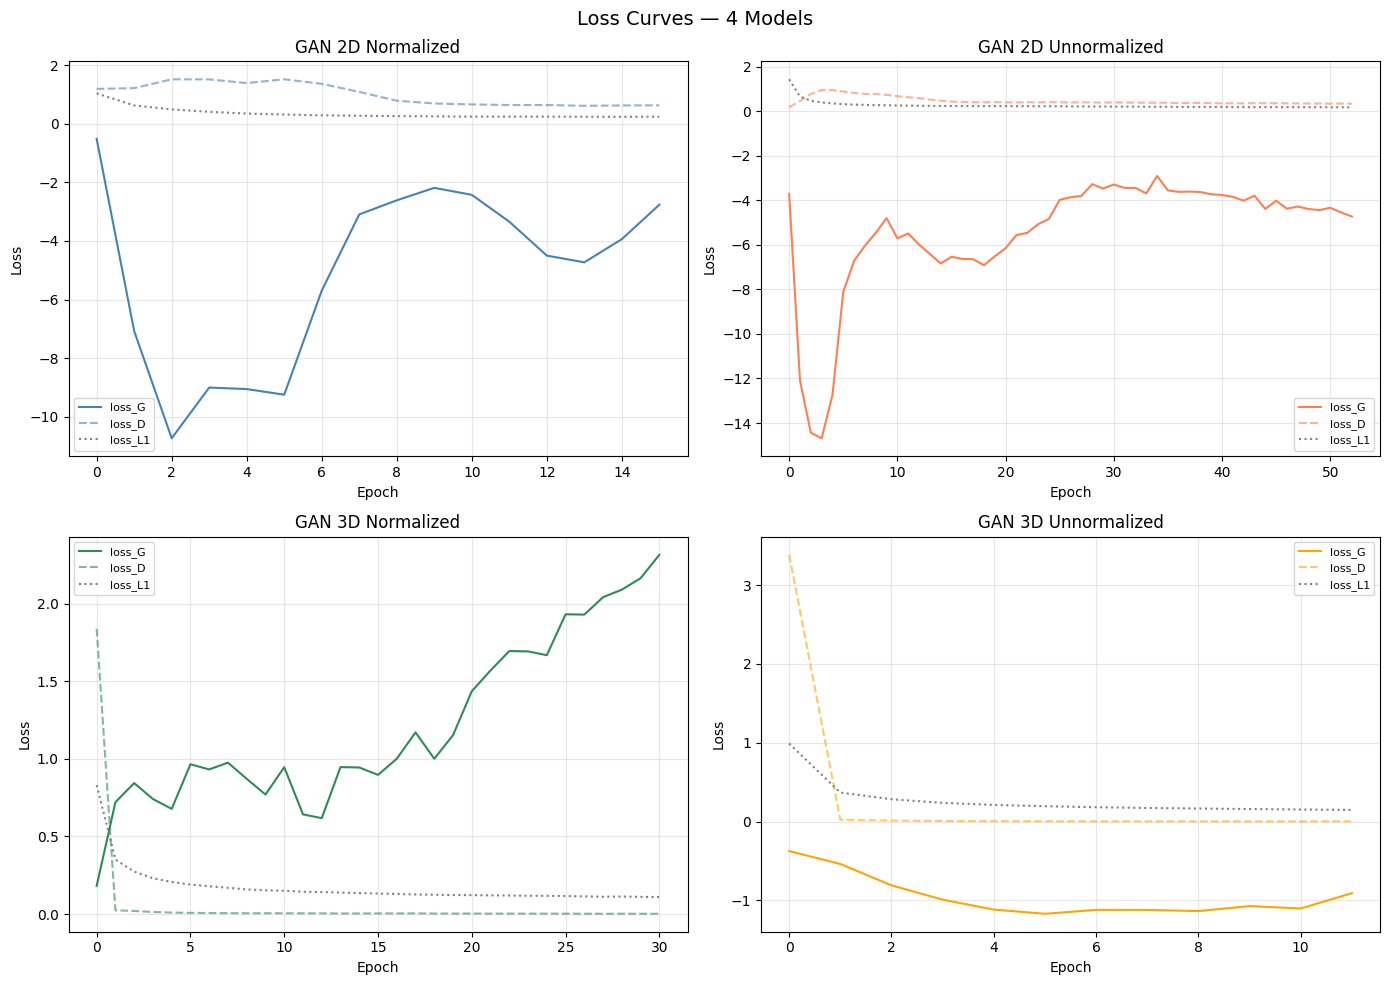

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loss Curves — 4 Models', fontsize=14)

models = [
    (ck2n['history'], 'GAN 2D Normalized',   'steelblue'),
    (ck2u['history'], 'GAN 2D Unnormalized', 'coral'),
    (ck3n['history'], 'GAN 3D Normalized',   'seagreen'),
    (ck3u['history'], 'GAN 3D Unnormalized', 'orange'),
]

for ax, (hist, label, color) in zip(axes.flat, models):
    ax.plot(hist['loss_G'],  label='loss_G',  color=color)
    ax.plot(hist['loss_D'],  label='loss_D',  color=color, linestyle='--', alpha=0.6)
    ax.plot(hist['loss_L1'], label='loss_L1', color='gray', linestyle=':')
    ax.set_title(label)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/loss_curves.png', dpi=100)
plt.show()


## Bước 7: So sánh SSIM và Loss_G

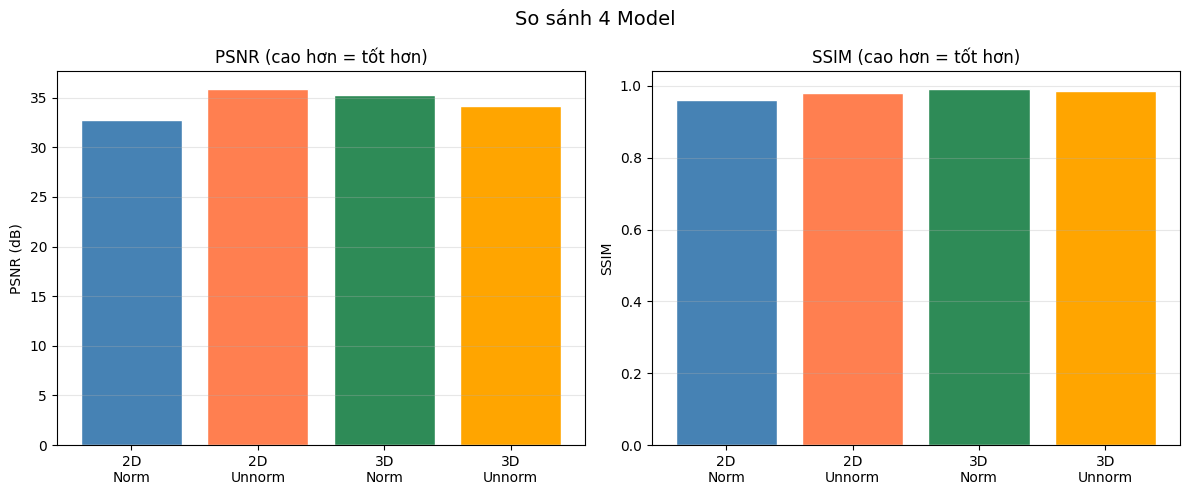

In [11]:
names       = list(results.keys())
short_names = ['2D\nNorm', '2D\nUnnorm', '3D\nNorm', '3D\nUnnorm']
ssim_vals   = [results[n]['ssim'] for n in names]
psnr_vals   = [results[n]['psnr'] for n in names]
colors      = ['steelblue', 'coral', 'seagreen', 'orange']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('So sánh 4 Model', fontsize=14)

axes[0].bar(short_names, psnr_vals, color=colors, edgecolor='white')
axes[0].set_title('PSNR (cao hơn = tốt hơn)')
axes[0].set_ylabel('PSNR (dB)')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(short_names, ssim_vals, color=colors, edgecolor='white')
axes[1].set_title('SSIM (cao hơn = tốt hơn)')
axes[1].set_ylabel('SSIM')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/comparison_chart.png', dpi=100)
plt.show()

## Bước 8: Real vs Fake — Kiểm tra chất lượng ảnh sinh ra

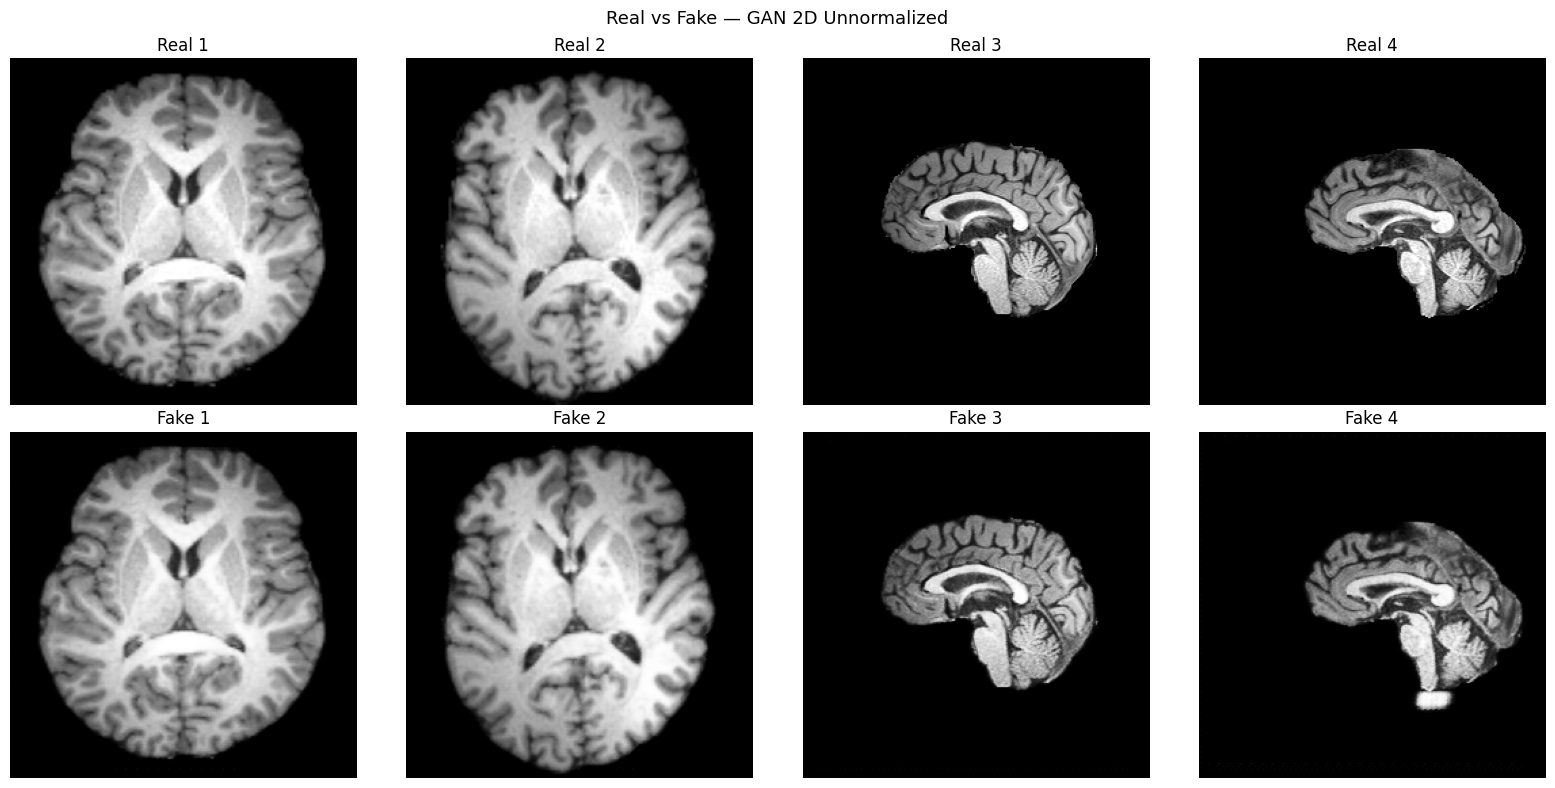

In [12]:
# Lấy 4 sample từ loader 2D unnormalized (model tốt nhất 2D)
G2D_unnorm.eval()
real_samples, age_samples = next(iter(loader_2d_unnorm))
real_samples = real_samples[:4].to(DEVICE)
age_samples  = age_samples[:4].to(DEVICE)

with torch.no_grad():
    fake_samples = G2D_unnorm(real_samples, age_samples)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Real vs Fake — GAN 2D Unnormalized', fontsize=13)

for i in range(4):
    real_np = (real_samples[i, 0].cpu().numpy() + 1) / 2
    fake_np = (fake_samples[i, 0].cpu().numpy() + 1) / 2

    axes[0][i].imshow(real_np, cmap='gray')
    axes[0][i].set_title(f'Real {i+1}')
    axes[0][i].axis('off')

    axes[1][i].imshow(fake_np, cmap='gray')
    axes[1][i].set_title(f'Fake {i+1}')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/real_vs_fake.png', dpi=100)
plt.show()
